In [1]:
import pandas as pd

In [2]:
raw_df = pd.read_csv(
    "chat.txt",
    delimiter=",",
    header=None,
    on_bad_lines="skip",
    encoding="utf8"
)

In [3]:
raw_df

,0,1,2,3
0,18/07/22,6:25 pm - Messages and calls are end-to-end e...,listen to,or share them. *Learn more*
1,18/07/22,6:25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna,is the instance working? This Akshaya from hc...,NaN
2,18/07/22,6:26 pm - Ram: Yes working,NaN,NaN
3,18/07/22,6:27 pm - ✌️Trio Tech Akshaya😇: This message ...,NaN,NaN
4,18/07/22,6:27 pm - ✌️Trio Tech Akshaya😇: Okay tks anna,NaN,NaN
...,...,...,...,...
3453,25/06/26,12:44 pm - ✌️Trio Tech Akshaya😇: Yes annaa,NaN,NaN
3454,25/06/26,12:44 pm - ✌️Trio Tech Akshaya😇: Kupadra,NaN,NaN
3455,25/06/26,12:49 pm - Ram: Ok,NaN,NaN
3456,27/06/26,5:50 pm - Ram: Send the link here,NaN,NaN


In [7]:
raw_df.drop(raw_df.columns[2], axis=1, inplace=True)

In [8]:
raw_df.columns = ['Date', 'Chat']

In [9]:
Message = raw_df["Chat"].str.split("-",n=1,expand=True)
Message

,0,1
0,6:25 pm,Messages and calls are end-to-end encrypted. ...
1,6:25 pm,✌️Trio Tech Akshaya😇: Hi Ram Anna
2,6:26 pm,Ram: Yes working
3,6:27 pm,✌️Trio Tech Akshaya😇: This message was deleted
4,6:27 pm,✌️Trio Tech Akshaya😇: Okay tks anna
...,...,...
3453,12:44 pm,✌️Trio Tech Akshaya😇: Yes annaa
3454,12:44 pm,✌️Trio Tech Akshaya😇: Kupadra
3455,12:49 pm,Ram: Ok
3456,5:50 pm,Ram: Send the link here


In [10]:
raw_df["Time"] = Message[0]

In [11]:
Message1 = Message[1].str.split(":",n=1,expand=True)
Message1

,0,1
0,Messages and calls are end-to-end encrypted. ...,None
1,✌️Trio Tech Akshaya😇,Hi Ram Anna
2,Ram,Yes working
3,✌️Trio Tech Akshaya😇,This message was deleted
4,✌️Trio Tech Akshaya😇,Okay tks anna
...,...,...
3453,✌️Trio Tech Akshaya😇,Yes annaa
3454,✌️Trio Tech Akshaya😇,Kupadra
3455,Ram,Ok
3456,Ram,Send the link here


In [12]:
raw_df["Name"] = Message1[0]
raw_df["Chat"] = Message1[1]
raw_df

,Date,Chat,Time,Name
0,18/07/22,None,6:25 pm,Messages and calls are end-to-end encrypted. ...
1,18/07/22,Hi Ram Anna,6:25 pm,✌️Trio Tech Akshaya😇
2,18/07/22,Yes working,6:26 pm,Ram
3,18/07/22,This message was deleted,6:27 pm,✌️Trio Tech Akshaya😇
4,18/07/22,Okay tks anna,6:27 pm,✌️Trio Tech Akshaya😇
...,...,...,...,...
3453,25/06/26,Yes annaa,12:44 pm,✌️Trio Tech Akshaya😇
3454,25/06/26,Kupadra,12:44 pm,✌️Trio Tech Akshaya😇
3455,25/06/26,Ok,12:49 pm,Ram
3456,27/06/26,Send the link here,5:50 pm,Ram


In [13]:
import pandas as pd
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ---------------------------------------------------------
# 1. Check your existing dataset
# ---------------------------------------------------------

print("Flirt Encounters:")

message_counts = raw_df["Name"].value_counts()

most_talkative_user = message_counts.idxmax()
least_talkative_user = message_counts.idxmin()

print(f"Talkative: {most_talkative_user}")
print(f"Less Talkative: {least_talkative_user}")


# ---------------------------------------------------------
# 2. Add flirty and non-flirty training sentences
# ---------------------------------------------------------

flirty_sentences = [
    "Hey, you look beautiful today!",
    "You are so cute.",
    "I was thinking about you.",
    "I miss you so much.",
    "You look amazing.",
    "I love talking to you.",
    "You always make me smile.",
    "Can I take you out for coffee?",
    "You have such a beautiful smile.",
    "I can't stop thinking about you.",
    "You are really sweet.",
    "Sending you hugs and kisses.",
    "I would love to see you tonight.",
    "You make my heart happy.",
    "You look gorgeous today.",
    "I wish you were here with me.",
    "I really like spending time with you.",
    "You are making me blush 😉",
    "I think you are adorable.",
    "I love your smile."
]

non_flirty_sentences = [
    "What time is the meeting?",
    "Please send me the document.",
    "I will call you tomorrow.",
    "The weather is nice today.",
    "Can you help me with this project?",
    "I finished my homework.",
    "The train is arriving at 5 PM.",
    "Please bring your laptop.",
    "Where is the nearest restaurant?",
    "I have an appointment tomorrow.",
    "The report is ready.",
    "Can you send me the file?",
    "I am going to the office.",
    "The class starts at nine.",
    "Please check your email.",
    "I need to buy some groceries.",
    "What is the meeting agenda?",
    "I will be late today.",
    "Let's discuss the project.",
    "Can you explain this problem?"
]


# ---------------------------------------------------------
# 3. Create labelled DataFrame
# ---------------------------------------------------------

flirty_raw_df = pd.DataFrame({
    'Chat': flirty_sentences,
    'Flirtatious': 1
})

non_flirty_raw_df = pd.DataFrame({
    'Chat': non_flirty_sentences,
    'Flirtatious': 0
})


# Combine the new labelled data
training_data = pd.concat(
    [flirty_raw_df, non_flirty_raw_df],
    ignore_index=True
)


# ---------------------------------------------------------
# 4. Add labels to your existing dataset using keywords
# ---------------------------------------------------------

flirt_keywords = [
    'hey',
    'great',
    'thinking about you',
    'sweet',
    '😉',
    'love',
    'beautiful',
    'cute',
    'miss you',
    'hugs',
    'kisses',
    'us',
    'coffee',
    'amazing'
]


def is_flirtatious(message):

    if pd.isna(message):
        return 0

    message = str(message).lower()

    return int(
        any(keyword in message for keyword in flirt_keywords)
    )


# Create an initial label for your existing dataset
df['Flirtatious'] = raw_df['Chat'].apply(is_flirtatious)


# ---------------------------------------------------------
# 5. Combine existing dataset with labelled sentences
# ---------------------------------------------------------

existing_data = raw_df[['Chat', 'Flirtatious']].copy()

training_data = pd.concat(
    [existing_data, training_data],
    ignore_index=True
)


# Remove empty messages
training_data = training_data.dropna(subset=['Chat'])

# Remove duplicate messages
training_data = training_data.drop_duplicates(subset=['Chat'])

# Make sure labels are integers
training_data['Flirtatious'] = training_data['Flirtatious'].astype(int)


# ---------------------------------------------------------
# 6. Display the labelled dataset
# ---------------------------------------------------------

print("\nLabelled Dataset:")
print(training_data[['Chat', 'Flirtatious']].head(20))

print("\nLabel Counts:")
print(training_data['Flirtatious'].value_counts())


# ---------------------------------------------------------
# 7. Prepare data for classification
# ---------------------------------------------------------

X = training_data['Chat']
y = training_data['Flirtatious']


# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ---------------------------------------------------------
# 8. Create TF-IDF + Logistic Regression model
# ---------------------------------------------------------

model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        max_features=5000
    )),

    ('classifier', LogisticRegression(
        max_iter=1000
    ))
])


# ---------------------------------------------------------
# 9. Train the classification model
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# 10. Test the model
# ---------------------------------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(f"{accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Flirty', 'Flirty']
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# ---------------------------------------------------------
# 11. Predict new messages
# ---------------------------------------------------------

new_messages = [
    "You look really beautiful today",
    "Can you send me the report?",
    "I miss you and I wish you were here",
    "What time does the meeting start?",
    "You are so cute 😉",
    "Please send me the project file"
]


predictions = model.predict(new_messages)

probabilities = model.predict_proba(new_messages)


print("\nPredictions:")

for message, prediction, probability in zip(
    new_messages,
    predictions,
    probabilities
):

    label = "FLIRTY" if prediction == 1 else "NOT FLIRTY"

    confidence = probability[prediction] * 100

    print(f"\nMessage: {message}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2f}%")

Flirt Encounters:
Talkative:  ✌️Trio Tech Akshaya😇
Less Talkative:  Messages and calls are end-to-end encrypted. Only people in this chat can read


KeyError: "['Flirtatious'] not in index"

In [14]:
training_data

,Chat,Flirtatious
0,"Hey, you look beautiful today!",1
1,You are so cute.,1
2,I was thinking about you.,1
3,I miss you so much.,1
4,You look amazing.,1
5,I love talking to you.,1
6,You always make me smile.,1
7,Can I take you out for coffee?,1
8,You have such a beautiful smile.,1
9,I can't stop thinking about you.,1


In [15]:
import pandas as pd

# ---------------------------------------------------------
# 1. Define flirty keywords and phrases
# ---------------------------------------------------------

flirt_keywords = [
    "cute",
    "beautiful",
    "wink",
    "date",
    "love",
    "handsome",
    "gorgeous",
    "sweet",
    "amazing",
    "adorable",
    "miss you",
    "thinking about you",
    "kiss",
    "kisses",
    "hug",
    "hugs",
    "😉",
    "❤️"
]


# ---------------------------------------------------------
# 2. Flirt detection function
# ---------------------------------------------------------

def is_flirtatious(message):

    if pd.isna(message):
        return 0

    message = str(message).lower()

    # Check complete message for keywords/phrases
    return int(
        any(keyword in message for keyword in flirt_keywords)
    )


# ---------------------------------------------------------
# 3. Add Flirtatious label to dataset
# ---------------------------------------------------------

raw_df['Flirtatious'] = raw_df['Chat'].apply(is_flirtatious)


# ---------------------------------------------------------
# 4. Show labelled messages
# ---------------------------------------------------------

print("Labelled Messages:")
print(raw_df[['Name', 'Chat', 'Flirtatious']].head(20))


# ---------------------------------------------------------
# 5. Calculate flirt percentage by user
# ---------------------------------------------------------

flirt_percentage_by_user = raw_df.groupby('Name').agg(
    Total_Messages=('Chat', 'count'),
    Flirtatious_Messages=('Flirtatious', 'sum')
)

flirt_percentage_by_user['Flirt_Percentage'] = (
    flirt_percentage_by_user['Flirtatious_Messages']
    / flirt_percentage_by_user['Total_Messages']
    * 100
).fillna(0)

print("\nFlirt Percentage By User:")
print(flirt_percentage_by_user)

Labelled Messages:
                                                 Name  \
0    Messages and calls are end-to-end encrypted. ...   
1                                ✌️Trio Tech Akshaya😇   
2                                                 Ram   
3                                ✌️Trio Tech Akshaya😇   
4                                ✌️Trio Tech Akshaya😇   
5                                                 Ram   
6                                ✌️Trio Tech Akshaya😇   
7                                ✌️Trio Tech Akshaya😇   
8                                                 Ram   
9                                ✌️Trio Tech Akshaya😇   
10                               ✌️Trio Tech Akshaya😇   
11                               ✌️Trio Tech Akshaya😇   
12                                                Ram   
13                                                Ram   
14                                                Ram   
15                               ✌️Trio Tech Akshaya😇   
16          

In [17]:
# Display only the flirt percentage values
flirt_percentage_values = flirt_percentage_by_user['Flirt_Percentage']
print(flirt_percentage_values)

Name
Ram                                      0.598291
✌️Trio Tech Akshaya😇                     0.706090
✌️Trio Tech Akshaya😇 pinned a message    0.000000
Name: Flirt_Percentage, dtype: float64


#TIME ENCOUNTERS MUST CONVERT 'Date' column is converted to datetime format

In [16]:
date_counts = raw_df['Date'].value_counts()

In [17]:
date_counts

Date
15/02/23    75
05/02/23    57
26/08/22    57
05/09/22    51
12/09/22    50
            ..
24/05/25     1
02/09/22     1
05/09/24     1
03/06/25     1
29/07/23     1
Name: count, Length: 334, dtype: int64

In [18]:
most_active_date = date_counts.idxmax()
most_active_date

'15/02/23'

In [19]:
print(f"The most active date is: {most_active_date}")

The most active date is: 15/02/23


In [21]:
raw_df['Date'] = pd.to_datetime(raw_df['Date'], format='%d/%m/%y', dayfirst=True, errors='coerce')
#errors='coerce': Invalid parsing will be set as NaN.
# Check for any invalid dates
if pd.api.types.is_datetime64_any_dtype(raw_df['Date']):# datetime irundha dhan week day display hagum(upper line also need)
    print(f"Time Encounters")
    print(f"Most Active Date: {most_active_date}")
    # Extract the day of the week and create a new column
    raw_df['Day_of_Week'] = raw_df['Date'].dt.day_name()
    date_counts = raw_df['Day_of_Week'].value_counts()
    # Get the most active day
    most_active_day = date_counts.idxmax()
    # Display the results
    print(f"Most Active Day: {most_active_day}")


Time Encounters
Most Active Date: 15/02/23
Most Active Day: Friday


In [23]:
raw_df['Date'] = pd.to_datetime(raw_df['Date'], format='%d/%m/%y', dayfirst=True, errors='coerce')
#errors='coerce': Invalid parsing will be set as NaN.
# Check for any invalid dates
if pd.api.types.is_datetime64_any_dtype(raw_df['Date']):# datetime irundha dhan week day display hagum(upper line also need)
    print(f"Time Encounters")
    print(f"Most Active Date: {most_active_date}")
    # Extract the day of the week and create a new column
    raw_df['Day_of_Week'] = raw_df['Date'].dt.day_name()
    date_counts = raw_df['Day_of_Week'].value_counts()
    # Get the most active day
    most_active_day = date_counts.idxmax()
    # Display the results
    print(f"Most Active Day: {most_active_day}")

# Convert 'Date' column to datetime format with error handling
raw_df['Date'] = pd.to_datetime(raw_df['Date'], format='%d/%m/%y', dayfirst=True, errors='coerce')

# Convert 'Time' column to datetime format with error handling
raw_df['Time'] = pd.to_datetime(raw_df['Time'], format='%H:%M', errors='coerce')


# Combine 'Date' and 'Time' into a single datetime column
raw_df['DateTime'] = raw_df['Date'].combine_first(raw_df['Time'])

# Extract the hour from the combined datetime
raw_df['Hour'] = raw_df['DateTime'].dt.hour

# Count the number of messages per hour
active_hour_counts = raw_df['Hour'].value_counts().sort_index()

# Get the most active hour
if not active_hour_counts.empty:
    most_active_hour = active_hour_counts.idxmax()
    most_active_count = active_hour_counts.max()
    
    # Print the result
    print(f"The most active hour is: {most_active_hour}:00")
else:
    print("There are no messages in the DataFrame or all hours have NaT values.")
    
# Group by date and count the number of messages
messages_per_day = raw_df.groupby(raw_df['Date'].dt.date).size()

# Calculate the average number of messages per day
average_messages_per_day = messages_per_day.mean()

# Print the result
print(f"The average number of messages per day is: {average_messages_per_day:.2f}")

Time Encounters
Most Active Date: 15/02/23
Most Active Day: Friday
The most active hour is: 0.0:00
The average number of messages per day is: 10.88


#MEDIA ENCOUNTERS 'Date' column is converted to datetime format

In [24]:
print(f"Media Encounters")

# Define criteria for media messages
media_keywords = ['Media omitted']
# Count media messages
media_count = raw_df[raw_df['Chat'].str.contains('|'.join(media_keywords), na=False)].shape[0]
#na=False: This argument ensures that any NaN values in the 'Chat' column are treated as False, meaning they won't be counted as matches.
# Print the result
print(f"Media Count: {media_count}")

# Define criteria for deleted messages
deleted_keywords = ['deleted', 'This message was deleted', 'Message deleted']
# Count deleted messages
deleted_count = raw_df[raw_df['Chat'].str.contains('|'.join(deleted_keywords), case=False, na=False)].shape[0]
# Print the result
print(f"Deleted Message Count: {deleted_count}")

# Define criteria for missed voice calls
missed_call_keywords = ['Missed call', 'Missed voice call']
# Count missed voice calls
missed_call_count = raw_df[raw_df['Chat'].str.contains('|'.join(missed_call_keywords), case=False, na=False)].shape[0]
# Print the result
print(f"Missed Voice Call Count: {missed_call_count}")

# Define criteria for missed voice calls
missed_call_keywords = ['Missed call', 'Missed video call']
# Count missed voice calls
missed_call_count = raw_df[raw_df['Chat'].str.contains('|'.join(missed_call_keywords), case=False, na=False)].shape[0]
# Print the result
print(f"Missed Video Call Count: {missed_call_count}")




Media Encounters
Media Count: 143
Deleted Message Count: 17
Missed Voice Call Count: 5
Missed Video Call Count: 1


#PERFORM SENTIMENT ANALYSIS

In [28]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [29]:
dataset=raw_df
dataset

,Date,Chat,Time,Name,Flirtatious,Day_of_Week,DateTime,Hour


In [39]:
raw_df.rename(columns={0: 'Date', 1: 'Chat'}, inplace=True)

print(raw_df[['Date', 'Chat', 'Compound']].head())

       Date                                               Chat  Compound
0  18/07/22   6:25 pm - Messages and calls are end-to-end e...    0.0000
1  18/07/22        6:25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna    0.0000
2  18/07/22                         6:26 pm - Ram: Yes working    0.4019
3  18/07/22   6:27 pm - ✌️Trio Tech Akshaya😇: This message ...    0.0000
4  18/07/22      6:27 pm - ✌️Trio Tech Akshaya😇: Okay tks anna    0.2263


In [40]:
raw_df['Compound'] = raw_df['Chat'].apply(
    lambda x: sid.polarity_scores(str(x))['compound']
)

In [41]:
dataset.dropna(inplace=True)

In [42]:
sid = SentimentIntensityAnalyzer()

In [43]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [44]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sid = SentimentIntensityAnalyzer()

dataset['Compound'] = dataset['Chat'].fillna('').apply(
    lambda text: sid.polarity_scores(str(text))['compound']
)

print(dataset[['Chat', 'Compound']])

Empty DataFrame
Columns: [Chat, Compound]
Index: []


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [47]:
sent = sid.polarity_scores(str(raw_df.iloc[4, 1]))
print(sent)

{'neg': 0.0, 'neu': 0.787, 'pos': 0.213, 'compound': 0.2263}


In [34]:
print(dataset.index)
print(dataset['Chat'].head())

Index([], dtype='int64')
Series([], Name: Chat, dtype: object)


In [48]:
print(df.shape)
print(df.head())
print(df.columns)

(3458, 5)
          0                                                  1  \
0  18/07/22   6:25 pm - Messages and calls are end-to-end e...   
1  18/07/22        6:25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna   
2  18/07/22                         6:26 pm - Ram: Yes working   
3  18/07/22   6:27 pm - ✌️Trio Tech Akshaya😇: This message ...   
4  18/07/22      6:27 pm - ✌️Trio Tech Akshaya😇: Okay tks anna   

                                                   2  \
0                                          listen to   
1   is the instance working? This Akshaya from hc...   
2                                                NaN   
3                                                NaN   
4                                                NaN   

                              3  Flirtatious  
0   or share them. *Learn more*            0  
1                           NaN            0  
2                           NaN            0  
3                           NaN            0  
4                    

In [1]:
import pandas as pd

df = pd.read_csv("chat.txt",delimiter=',', header=None, on_bad_lines='skip', encoding='utf8')

print(df.shape)
print(df.head())

(3458, 4)
          0                                                  1  \
0  18/07/22   6:25 pm - Messages and calls are end-to-end e...   
1  18/07/22        6:25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna   
2  18/07/22                         6:26 pm - Ram: Yes working   
3  18/07/22   6:27 pm - ✌️Trio Tech Akshaya😇: This message ...   
4  18/07/22      6:27 pm - ✌️Trio Tech Akshaya😇: Okay tks anna   

                                                   2  \
0                                          listen to   
1   is the instance working? This Akshaya from hc...   
2                                                NaN   
3                                                NaN   
4                                                NaN   

                              3  
0   or share them. *Learn more*  
1                           NaN  
2                           NaN  
3                           NaN  
4                           NaN  


In [54]:
print(data_Senti.shape)
print(data_Senti.head())

(0, 15)
Empty DataFrame
Columns: [Date, Chat, Time, Name, Flirtatious, Day_of_Week, DateTime, Hour, Compound, scores, compound, Negtive, Postive, Neutral, comp_score]
Index: []


In [55]:
data_Senti = raw_df.copy()

data_Senti.rename(
    columns={
        0: 'Date',
        1: 'Chat'
    },
    inplace=True
)

print(data_Senti.shape)
print(data_Senti[['Date', 'Chat', 'Compound']].head())

(3458, 5)
       Date                                               Chat  Compound
0  18/07/22   6:25 pm - Messages and calls are end-to-end e...    0.0000
1  18/07/22        6:25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna    0.0000
2  18/07/22                         6:26 pm - Ram: Yes working    0.4019
3  18/07/22   6:27 pm - ✌️Trio Tech Akshaya😇: This message ...    0.0000
4  18/07/22      6:27 pm - ✌️Trio Tech Akshaya😇: Okay tks anna    0.2263


In [56]:
scores = data_Senti['Chat'].apply(
    lambda x: sid.polarity_scores(str(x))
)

data_Senti['Negative'] = scores.apply(lambda x: x['neg'])
data_Senti['Neutral'] = scores.apply(lambda x: x['neu'])
data_Senti['Positive'] = scores.apply(lambda x: x['pos'])
data_Senti['Compound'] = scores.apply(lambda x: x['compound'])

print(data_Senti[['Chat', 'Negative', 'Neutral', 'Positive', 'Compound']].head())

                                                Chat  Negative  Neutral  \
0   6:25 pm - Messages and calls are end-to-end e...       0.0    1.000   
1        6:25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna       0.0    1.000   
2                         6:26 pm - Ram: Yes working       0.0    0.597   
3   6:27 pm - ✌️Trio Tech Akshaya😇: This message ...       0.0    1.000   
4      6:27 pm - ✌️Trio Tech Akshaya😇: Okay tks anna       0.0    0.787   

   Positive  Compound  
0     0.000    0.0000  
1     0.000    0.0000  
2     0.403    0.4019  
3     0.000    0.0000  
4     0.213    0.2263  


In [60]:
 def sentimentalAnalysis(data_Senti,columnname):
        
        #downloading vader_lexicon for the process
        import matplotlib.pyplot as plt
        import seaborn as sns
        "Importing Necessary Packeage"
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sid = SentimentIntensityAnalyzer()
        
        "Deleting null pr empty value"
        data_Senti.dropna(inplace=True)
        
        "Checking for a comment"
        #sid.polarity_scores(data[columnname][93])
        
        "Creating respective columns"
        
        data_Senti['scores'] = data_Senti[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
        data_Senti['compound']  = data_Senti['scores'].apply(lambda score_dict: score_dict['compound'])
        data_Senti['Negtive']  = data_Senti['scores'].apply(lambda score_dict: score_dict['neg'])
        data_Senti['Postive']  = data_Senti['scores'].apply(lambda score_dict: score_dict['pos'])
        data_Senti['Neutral']  = data_Senti['scores'].apply(lambda score_dict: score_dict['neu'])
        
        "Creating final pos or neg using compound score"
        data_Senti['comp_score'] = data_Senti['compound'].apply(lambda c: 'pos' if c >=0 else 'neg')
        plt.clf()
        #comp=sns.countplot(x = 'comp_score', hue = 'Name', data = data, palette = 'magma')
        #comp.figure.savefig("date_charts.png")
        "Checking how many pos and neg"
        posneg=pd.DataFrame(data_Senti['comp_score'].value_counts())
        return posneg,data_Senti
    

In [61]:
pos,data_Senti=sentimentalAnalysis(dataset,columnname='Chat') #already inbuily function just give columnname

<Figure size 640x480 with 0 Axes>

In [62]:
data_Senti

,Date,Chat,Time,Name,Flirtatious,Day_of_Week,DateTime,Hour,Compound,scores,compound,Negtive,Postive,Neutral,comp_score


In [63]:
import pandas as pd

raw_df = pd.read_csv(
    "chat.txt",
    delimiter=",",
    header=None,
    on_bad_lines="skip",
    encoding="utf8"
)

print("raw_df shape:", raw_df.shape)

raw_df shape: (3458, 4)


In [64]:
data_Senti = raw_df.copy()

data_Senti['Chat'] = data_Senti[1]

data_Senti['Compound'] = data_Senti['Chat'].apply(
    lambda x: sid.polarity_scores(str(x))['compound']
)

print(data_Senti.shape)
print(data_Senti[['Chat', 'Compound']].head())

(3458, 6)
                                                Chat  Compound
0   6:25 pm - Messages and calls are end-to-end e...    0.0000
1        6:25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna    0.0000
2                         6:26 pm - Ram: Yes working    0.4019
3   6:27 pm - ✌️Trio Tech Akshaya😇: This message ...    0.0000
4      6:27 pm - ✌️Trio Tech Akshaya😇: Okay tks anna    0.2263


In [65]:
print(data_Senti.head(10).to_string())
print("Number of rows:", len(data_Senti))

          0                                                                                               1                                                           2                             3                                                                                            Chat  Compound
0  18/07/22        6:25 pm - Messages and calls are end-to-end encrypted. Only people in this chat can read                                                   listen to   or share them. *Learn more*        6:25 pm - Messages and calls are end-to-end encrypted. Only people in this chat can read    0.0000
1  18/07/22                                                     6:25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna   is the instance working? This Akshaya from hcm trio tech!                           NaN                                                     6:25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna    0.0000
2  18/07/22                                                                      6:26 pm

In [66]:
print(data_Senti[['Chat', 'Compound']].head())

                                                Chat  Compound
0   6:25 pm - Messages and calls are end-to-end e...    0.0000
1        6:25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna    0.0000
2                         6:26 pm - Ram: Yes working    0.4019
3   6:27 pm - ✌️Trio Tech Akshaya😇: This message ...    0.0000
4      6:27 pm - ✌️Trio Tech Akshaya😇: Okay tks anna    0.2263


In [68]:
raw_df = pd.read_csv(
    "chat.txt",
    delimiter=",",
    header=None,
    on_bad_lines="skip",
    encoding="utf8"
)

In [69]:
data_Senti = raw_df.copy()

data_Senti['Chat'] = data_Senti[1]

data_Senti['Compound'] = data_Senti['Chat'].apply(
    lambda x: sid.polarity_scores(str(x))['compound']
)

In [70]:
print(data_Senti.shape)
print(data_Senti[['Chat', 'Compound']].head())

(3458, 6)
                                                Chat  Compound
0   6:25 pm - Messages and calls are end-to-end e...    0.0000
1        6:25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna    0.0000
2                         6:26 pm - Ram: Yes working    0.4019
3   6:27 pm - ✌️Trio Tech Akshaya😇: This message ...    0.0000
4      6:27 pm - ✌️Trio Tech Akshaya😇: Okay tks anna    0.2263


In [71]:
import re

data_Senti['Date'] = raw_df[0]

# Extract everything after " - "
data_Senti['Message'] = raw_df[1].astype(str)

# Extract time
data_Senti['Time'] = data_Senti['Message'].str.extract(
    r'^\s*(.*?)\s*-\s*'
)[0]

# Extract name
data_Senti['Name'] = data_Senti['Message'].str.extract(
    r'-\s*(.*?):\s*'
)[0]

# Extract actual chat
data_Senti['Chat'] = data_Senti['Message'].str.replace(
    r'^.*?:\s*',
    '',
    regex=True
)

print(data_Senti[['Date', 'Time', 'Name', 'Chat']].head())

       Date     Time                  Name  \
0  18/07/22  6:25 pm                   NaN   
1  18/07/22  6:25 pm  ✌️Trio Tech Akshaya😇   
2  18/07/22  6:26 pm                   Ram   
3  18/07/22  6:27 pm  ✌️Trio Tech Akshaya😇   
4  18/07/22  6:27 pm  ✌️Trio Tech Akshaya😇   

                                                Chat  
0  25 pm - Messages and calls are end-to-end encr...  
1          25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna  
2                           26 pm - Ram: Yes working  
3  27 pm - ✌️Trio Tech Akshaya😇: This message was...  
4        27 pm - ✌️Trio Tech Akshaya😇: Okay tks anna  


In [72]:
scores = data_Senti['Chat'].apply(
    lambda x: sid.polarity_scores(str(x))
)

data_Senti['Negative'] = scores.apply(lambda x: x['neg'])
data_Senti['Neutral'] = scores.apply(lambda x: x['neu'])
data_Senti['Positive'] = scores.apply(lambda x: x['pos'])
data_Senti['Compound'] = scores.apply(lambda x: x['compound'])

In [73]:
data_Senti['DateTime'] = pd.to_datetime(
    data_Senti['Date'] + ' ' + data_Senti['Time'],
    dayfirst=True,
    errors='coerce'
)

data_Senti['Day_of_Week'] = data_Senti['DateTime'].dt.day_name()
data_Senti['Hour'] = data_Senti['DateTime'].dt.hour

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5076\1829004673.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_Senti['DateTime'] = pd.to_datetime(


In [74]:
print(data_Senti.shape)

print(
    data_Senti[
        ['Date', 'Time', 'Name', 'Chat',
         'Day_of_Week', 'DateTime', 'Hour',
         'Negative', 'Neutral', 'Positive', 'Compound']
    ].head(10).to_string()
)

(3458, 16)
       Date     Time                  Name                                                                                         Chat Day_of_Week            DateTime  Hour  Negative  Neutral  Positive  Compound
0  18/07/22  6:25 pm                   NaN       25 pm - Messages and calls are end-to-end encrypted. Only people in this chat can read      Monday 2022-07-18 18:25:00  18.0     0.000    1.000     0.000    0.0000
1  18/07/22  6:25 pm  ✌️Trio Tech Akshaya😇                                                    25 pm - ✌️Trio Tech Akshaya😇: Hi Ram Anna      Monday 2022-07-18 18:25:00  18.0     0.000    1.000     0.000    0.0000
2  18/07/22  6:26 pm                   Ram                                                                     26 pm - Ram: Yes working      Monday 2022-07-18 18:26:00  18.0     0.000    0.597     0.403    0.4019
3  18/07/22  6:27 pm  ✌️Trio Tech Akshaya😇                                       27 pm - ✌️Trio Tech Akshaya😇: This message was deleted  

In [75]:
pos,data_Senti=sentimentalAnalysis(dataset,columnname='Chat') #already inbuily function just give columnname

<Figure size 640x480 with 0 Axes>

In [76]:
data_Senti

,Date,Chat,Time,Name,Flirtatious,Day_of_Week,DateTime,Hour,Compound,scores,compound,Negtive,Postive,Neutral,comp_score


In [78]:
import pandas as pd
import re
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

# Read original WhatsApp file
with open("chat.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

rows = []

# Handles:
# 18/07/22, 6:25 pm - Name: Message
# 18/07/22, 6:25 pm - Name: Message
pattern = re.compile(
    r'^(\d{1,2}/\d{1,2}/\d{2,4})'
    r'\s*,?\s*'
    r'(\d{1,2}:\d{2}\s*[apAP][mM])'
    r'\s*-\s*'
    r'(.*?):\s*(.*)$'
)

current = None

for line in lines:
    line = line.rstrip("\n\r")

    match = pattern.match(line)

    if match:
        # Save previous message
        if current is not None:
            rows.append(current)

        date, time, name, chat = match.groups()

        current = {
            "Date": date,
            "Time": time,
            "Name": name,
            "Chat": chat
        }

    elif current is not None:
        # Multi-line message
        current["Chat"] += " " + line.strip()

# Save last message
if current is not None:
    rows.append(current)

# Create DataFrame
data_Senti = pd.DataFrame(rows)

print("Number of messages:", len(data_Senti))
print("Columns:", data_Senti.columns.tolist())
print(data_Senti.head().to_string())

Number of messages: 3436
Columns: ['Date', 'Time', 'Name', 'Chat']
       Date     Time                  Name                                                                    Chat
0  18/07/22  6:25 pm  ✌️Trio Tech Akshaya😇  Hi Ram Anna, is the instance working? This Akshaya from hcm trio tech!
1  18/07/22  6:26 pm                   Ram                                                             Yes working
2  18/07/22  6:27 pm  ✌️Trio Tech Akshaya😇                                                This message was deleted
3  18/07/22  6:27 pm  ✌️Trio Tech Akshaya😇                                                           Okay tks anna
4  18/07/22  6:28 pm                   Ram                                            You are from EBS background?


In [79]:
data_Senti["DateTime"] = pd.to_datetime(
    data_Senti["Date"] + " " + data_Senti["Time"],
    dayfirst=True,
    errors="coerce"
)

data_Senti["Day_of_Week"] = data_Senti["DateTime"].dt.day_name()
data_Senti["Hour"] = data_Senti["DateTime"].dt.hour

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5076\3586677474.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_Senti["DateTime"] = pd.to_datetime(


In [80]:
scores = data_Senti["Chat"].apply(
    lambda x: sid.polarity_scores(str(x))
)

data_Senti["Negative"] = scores.apply(lambda x: x["neg"])
data_Senti["Neutral"] = scores.apply(lambda x: x["neu"])
data_Senti["Positive"] = scores.apply(lambda x: x["pos"])
data_Senti["Compound"] = scores.apply(lambda x: x["compound"])

In [81]:
print(data_Senti.shape)

print(
    data_Senti[
        ["Date", "Time", "Name", "Chat",
         "Day_of_Week", "Hour",
         "Negative", "Neutral", "Positive", "Compound"]
    ].head(10).to_string()
)

(3436, 11)
       Date     Time                  Name                                                                    Chat Day_of_Week  Hour  Negative  Neutral  Positive  Compound
0  18/07/22  6:25 pm  ✌️Trio Tech Akshaya😇  Hi Ram Anna, is the instance working? This Akshaya from hcm trio tech!      Monday    18     0.000    1.000     0.000    0.0000
1  18/07/22  6:26 pm                   Ram                                                             Yes working      Monday    18     0.000    0.270     0.730    0.4019
2  18/07/22  6:27 pm  ✌️Trio Tech Akshaya😇                                                This message was deleted      Monday    18     0.000    1.000     0.000    0.0000
3  18/07/22  6:27 pm  ✌️Trio Tech Akshaya😇                                                           Okay tks anna      Monday    18     0.000    0.513     0.487    0.2263
4  18/07/22  6:28 pm                   Ram                                            You are from EBS background?      Monday   

In [82]:
data_Senti

,Date,Time,Name,Chat,DateTime,Day_of_Week,Hour,Negative,Neutral,Positive,Compound
0,18/07/22,6:25 pm,✌️Trio Tech Akshaya😇,"Hi Ram Anna, is the instance working? This Aks...",2022-07-18 18:25:00,Monday,18,0.0,1.000,0.000,0.0000
1,18/07/22,6:26 pm,Ram,Yes working,2022-07-18 18:26:00,Monday,18,0.0,0.270,0.730,0.4019
2,18/07/22,6:27 pm,✌️Trio Tech Akshaya😇,This message was deleted,2022-07-18 18:27:00,Monday,18,0.0,1.000,0.000,0.0000
3,18/07/22,6:27 pm,✌️Trio Tech Akshaya😇,Okay tks anna,2022-07-18 18:27:00,Monday,18,0.0,0.513,0.487,0.2263
4,18/07/22,6:28 pm,Ram,You are from EBS background?,2022-07-18 18:28:00,Monday,18,0.0,1.000,0.000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
3431,25/06/26,12:44 pm,✌️Trio Tech Akshaya😇,Yes annaa,2026-06-25 12:44:00,Thursday,12,0.0,0.270,0.730,0.4019
3432,25/06/26,12:44 pm,✌️Trio Tech Akshaya😇,Kupadra,2026-06-25 12:44:00,Thursday,12,0.0,1.000,0.000,0.0000
3433,25/06/26,12:49 pm,Ram,Ok,2026-06-25 12:49:00,Thursday,12,0.0,0.000,1.000,0.2960
3434,27/06/26,5:50 pm,Ram,Send the link here,2026-06-27 17:50:00,Saturday,17,0.0,1.000,0.000,0.0000


In [85]:
print(data_Senti["Chat"].head(10).to_string())
print(data_Senti["Chat"].isna().sum())
print(len(data_Senti))

0    Hi Ram Anna, is the instance working? This Aks...
1                                          Yes working
2                             This message was deleted
3                                        Okay tks anna
4                         You are from EBS background?
5    No no from her recruitment background complete...
6                                  How about you Anna?
7                                       Can I call you
8                                          *am from hr
9                                             Yea sure
0
3436


In [86]:
data_Senti["comp_score"] = data_Senti["Chat"].apply(
    lambda x: sid.polarity_scores(str(x))["compound"]
)

In [87]:
print(data_Senti[["Chat", "comp_score"]].head(10))

                                                Chat  comp_score
0  Hi Ram Anna, is the instance working? This Aks...      0.0000
1                                        Yes working      0.4019
2                           This message was deleted      0.0000
3                                      Okay tks anna      0.2263
4                       You are from EBS background?      0.0000
5  No no from her recruitment background complete...     -0.2040
6                                How about you Anna?      0.0000
7                                     Can I call you      0.0000
8                                        *am from hr      0.0000
9                                           Yea sure      0.3182


In [88]:
print(data_Senti["comp_score"].dtype)
print(data_Senti["comp_score"].isna().sum())

float64
0


In [89]:
print(data_Senti.shape)
print(data_Senti[["Chat", "Compound"]].head(10))
print(data_Senti["Compound"].isna().sum())
print(data_Senti["Compound"].describe())

(3436, 12)
                                                Chat  Compound
0  Hi Ram Anna, is the instance working? This Aks...    0.0000
1                                        Yes working    0.4019
2                           This message was deleted    0.0000
3                                      Okay tks anna    0.2263
4                       You are from EBS background?    0.0000
5  No no from her recruitment background complete...   -0.2040
6                                How about you Anna?    0.0000
7                                     Can I call you    0.0000
8                                        *am from hr    0.0000
9                                           Yea sure    0.3182
0
count    3436.000000
mean        0.068568
std         0.193821
min        -0.796400
25%         0.000000
50%         0.000000
75%         0.000000
max         0.844900
Name: Compound, dtype: float64


In [91]:
data_Senti["comp_score"] = data_Senti["Compound"]

print(data_Senti[["Chat", "Compound", "comp_score"]].head(10))

                                                Chat  Compound  comp_score
0  Hi Ram Anna, is the instance working? This Aks...    0.0000      0.0000
1                                        Yes working    0.4019      0.4019
2                           This message was deleted    0.0000      0.0000
3                                      Okay tks anna    0.2263      0.2263
4                       You are from EBS background?    0.0000      0.0000
5  No no from her recruitment background complete...   -0.2040     -0.2040
6                                How about you Anna?    0.0000      0.0000
7                                     Can I call you    0.0000      0.0000
8                                        *am from hr    0.0000      0.0000
9                                           Yea sure    0.3182      0.3182


In [92]:
scores = data_Senti["Chat"].apply(
    lambda x: sid.polarity_scores(str(x))
)

data_Senti["Negative"] = scores.apply(lambda x: x["neg"])
data_Senti["Neutral"] = scores.apply(lambda x: x["neu"])
data_Senti["Positive"] = scores.apply(lambda x: x["pos"])
data_Senti["Compound"] = scores.apply(lambda x: x["compound"])

In [93]:
print(
    data_Senti[
        ["Chat", "Negative", "Neutral", "Positive", "Compound"]
    ].head(10)
)

                                                Chat  Negative  Neutral  \
0  Hi Ram Anna, is the instance working? This Aks...     0.000    1.000   
1                                        Yes working     0.000    0.270   
2                           This message was deleted     0.000    1.000   
3                                      Okay tks anna     0.000    0.513   
4                       You are from EBS background?     0.000    1.000   
5  No no from her recruitment background complete...     0.314    0.500   
6                                How about you Anna?     0.000    1.000   
7                                     Can I call you     0.000    1.000   
8                                        *am from hr     0.000    1.000   
9                                           Yea sure     0.000    0.303   

   Positive  Compound  
0     0.000    0.0000  
1     0.730    0.4019  
2     0.000    0.0000  
3     0.487    0.2263  
4     0.000    0.0000  
5     0.185   -0.2040  
6     

In [94]:
def sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

data_Senti["Sentiment"] = data_Senti["Compound"].apply(sentiment_label)

print(data_Senti[["Chat", "Compound", "Sentiment"]].head(20))

                                                 Chat  Compound Sentiment
0   Hi Ram Anna, is the instance working? This Aks...    0.0000   Neutral
1                                         Yes working    0.4019  Positive
2                            This message was deleted    0.0000   Neutral
3                                       Okay tks anna    0.2263  Positive
4                        You are from EBS background?    0.0000   Neutral
5   No no from her recruitment background complete...   -0.2040  Negative
6                                 How about you Anna?    0.0000   Neutral
7                                      Can I call you    0.0000   Neutral
8                                         *am from hr    0.0000   Neutral
9                                            Yea sure    0.3182  Positive
10                                                  👍    0.0000   Neutral
11                                                 Hi    0.0000   Neutral
12                 No need to use from

In [95]:
print(data_Senti["Sentiment"].value_counts())

Sentiment
Neutral     2449
Positive     805
Negative     182
Name: count, dtype: int64


In [99]:
selected_columns = data_Senti[['Name', 'Compound']]
print(selected_columns.head())

                   Name  Compound
0  ✌️Trio Tech Akshaya😇    0.0000
1                   Ram    0.4019
2  ✌️Trio Tech Akshaya😇    0.0000
3  ✌️Trio Tech Akshaya😇    0.2263
4                   Ram    0.0000


In [100]:
selected_columns

,Name,Compound
0,✌️Trio Tech Akshaya😇,0.0000
1,Ram,0.4019
2,✌️Trio Tech Akshaya😇,0.0000
3,✌️Trio Tech Akshaya😇,0.2263
4,Ram,0.0000
...,...,...
3431,✌️Trio Tech Akshaya😇,0.4019
3432,✌️Trio Tech Akshaya😇,0.0000
3433,Ram,0.2960
3434,Ram,0.0000


In [102]:
count_df = dff.groupby(['Name', 'Compound']).size().reset_index(name='count')

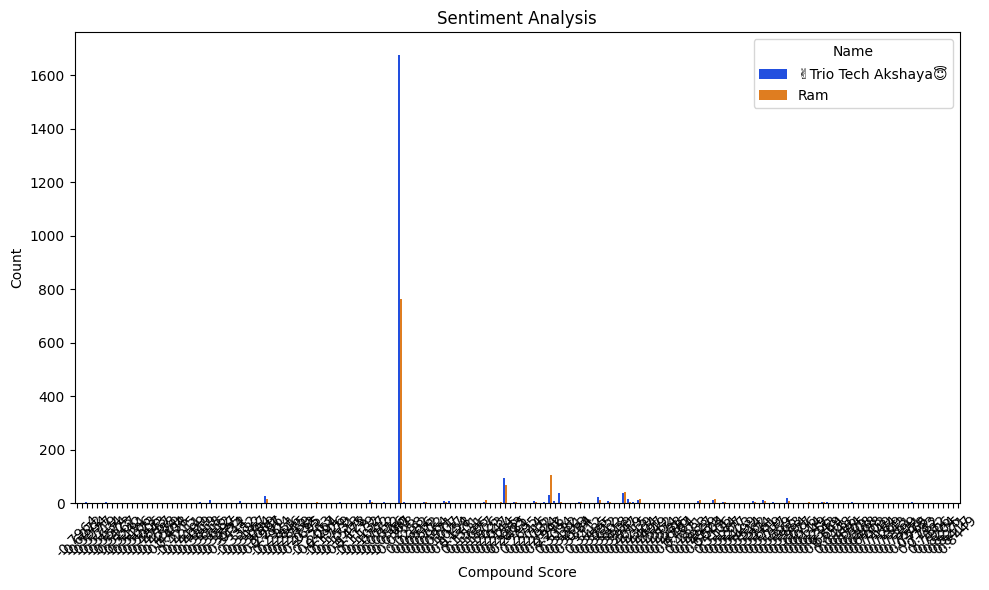

In [103]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x='Compound',
    y='count',
    hue='Name',
    data=count_df,
    palette='bright'
)

plt.title('Sentiment Analysis')
plt.xlabel('Compound Score')
plt.ylabel('Count')
plt.legend(title='Name')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [104]:
data_Senti['comp_score'] = data_Senti['Compound']

selected_columns = data_Senti[['Name', 'comp_score']]

print(selected_columns.head())

                   Name  comp_score
0  ✌️Trio Tech Akshaya😇      0.0000
1                   Ram      0.4019
2  ✌️Trio Tech Akshaya😇      0.0000
3  ✌️Trio Tech Akshaya😇      0.2263
4                   Ram      0.0000


In [105]:
dff = selected_columns

count_df = dff.groupby(
    ['Name', 'comp_score']
).size().reset_index(name='count')

In [106]:
dff

,Name,comp_score
0,✌️Trio Tech Akshaya😇,0.0000
1,Ram,0.4019
2,✌️Trio Tech Akshaya😇,0.0000
3,✌️Trio Tech Akshaya😇,0.2263
4,Ram,0.0000
...,...,...
3431,✌️Trio Tech Akshaya😇,0.4019
3432,✌️Trio Tech Akshaya😇,0.0000
3433,Ram,0.2960
3434,Ram,0.0000


In [107]:
def sentiment_label(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

data_Senti['Sentiment'] = data_Senti['Compound'].apply(sentiment_label)

count_df = (
    data_Senti
    .groupby(['Name', 'Sentiment'])
    .size()
    .reset_index(name='count')
)

print(count_df)

                   Name Sentiment  count
0                   Ram  Negative     49
1                   Ram   Neutral    766
2                   Ram  Positive    355
3  ✌️Trio Tech Akshaya😇  Negative    133
4  ✌️Trio Tech Akshaya😇   Neutral   1683
5  ✌️Trio Tech Akshaya😇  Positive    450


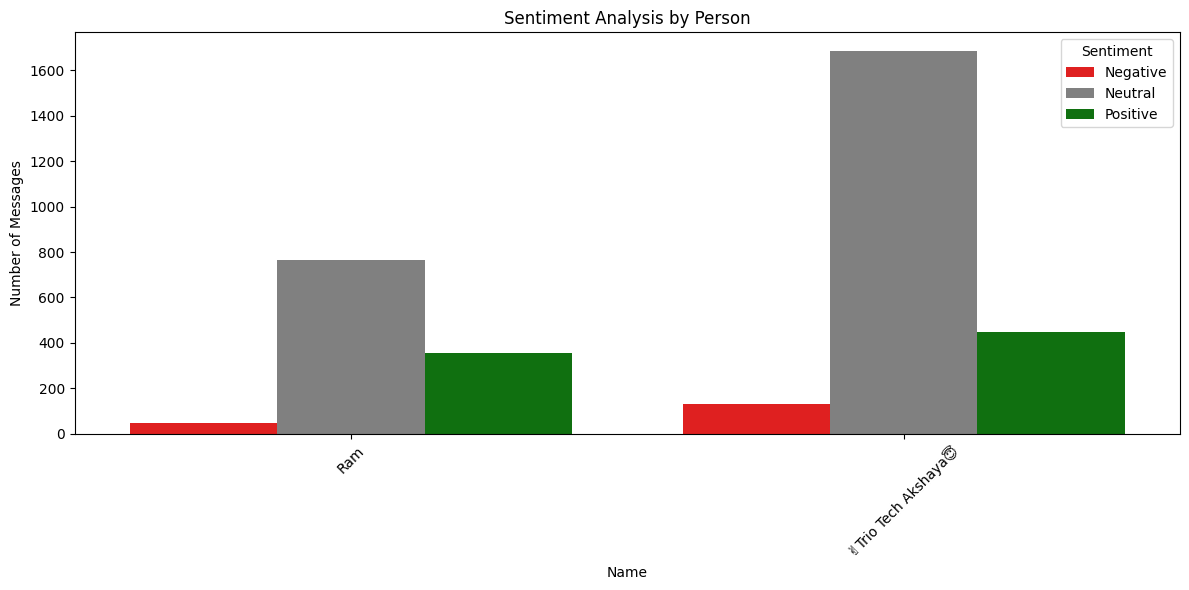

In [108]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x='Name',
    y='count',
    hue='Sentiment',
    data=count_df,
    palette={
        'Positive': 'green',
        'Neutral': 'gray',
        'Negative': 'red'
    }
)

plt.title('Sentiment Analysis by Person')
plt.xlabel('Name')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#TOPIC MODELLING

In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [111]:
import pandas as pd

# Assuming 'df' is your DataFrame
missing_count = data_Senti['Chat'].isnull().sum()
print(f"Missing values in 'Chat' column: {missing_count}")

# Display rows with missing values
rows_with_missing = data_Senti[data_Senti['Chat'].isnull()]
print(rows_with_missing)

Missing values in 'Chat' column: 0
Empty DataFrame
Columns: [Date, Time, Name, Chat, DateTime, Day_of_Week, Hour, Negative, Neutral, Positive, Compound, comp_score, Sentiment]
Index: []


In [112]:
data_Senti['Chat'].fillna('No message', inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5076\3275399378.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_Senti['Chat'].fillna('No message', inplace=True)


In [114]:
tfidf=TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')      # vector created  TEXT TO NUMBER
dtm=tfidf.fit_transform(data_Senti["Chat"])

In [115]:
from sklearn.decomposition import NMF               #NON MATRIX FACTORIZATION ALGM
nmf_model=NMF(n_components=5,random_state=42)    #5 topics need
nmf_model.fit(dtm)

NMF(n_components=5, random_state=42)

In [116]:
# Retrieve the top words for each topic
for index, topic in enumerate(nmf_model.components_):
    # Use get_feature_names_out() to retrieve feature names
    results = [tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]]
    print(f"{index + 0}: {[', '.join(results)]}")

0: ['uh, yeah, connect, hi, super, hello, joined, sure, yes, anna']
1: ['shall, hello, tmrw, 30, tomorrow, yes, joined, connect, omitted, media']
2: ['super, annaaaa, hmmm, mins, fine, connect, va, sure, oh, okay']
3: ['completed, amma, free, ana, sorry, ann, annaaa, annaaaa, akshaya, hi']
4: ['abba, know, let, ah, oh, msg, hahaha, come, sure, ok']


#WORD CLOUD

In [119]:
dataset=df
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [118]:
!pip install wordcloud

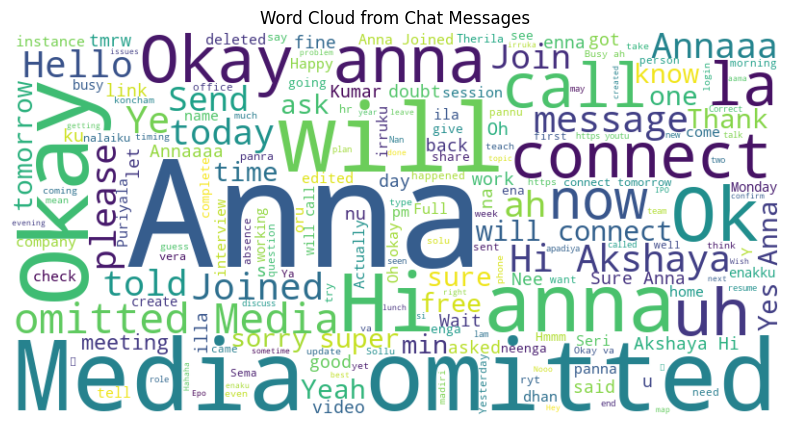

In [121]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Use the processed DataFrame
dataset = data_Senti

# Combine all chat messages into a single string
text = ' '.join(dataset['Chat'].dropna().astype(str))

# Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Chat Messages')
plt.show()